Imports and Setup


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [3]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


1. What is MNIST?

MNIST is a dataset of 70,000 handwritten digits (0–9), each a 28x28 grayscale image.
It’s the "Hello World" of deep learning — perfect for beginners to understand how
neural networks learn visual patterns.

⚙️ 2. Data Loading and Preprocessing
Convert each image to a tensor and normalize pixel values (0–255 -> 0–1)


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),           # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize to mean=0.5, std=0.5
])
transform

Compose(
    ToTensor()
    Normalize(mean=(0.5,), std=(0.5,))
)

In [5]:
train_dataset=datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_dataset=datasets.MNIST(root='./data',train=False,download=True,transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


In [6]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [7]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [8]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)



In [9]:
# dataiter = iter(train_loader)
# images, labels = dataiter()

# print(images.shape)
# print(labels.shape)

Define the Neural Network Model

In [10]:
class NeuraltNetwork(nn.Module):
  def __init__(self):
    super(NeuraltNetwork,self).__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(28*28, 128)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.2)
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
model = NeuraltNetwork().to(device)
print(model)



NeuraltNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Loss Function & Optimizer

In [11]:
criterion = nn.CrossEntropyLoss()
criterion

CrossEntropyLoss()

In [12]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

Step 5: Training Loop

In [13]:
epochs = 5
train_losses = []
for epoch in range(epochs):
  running_loss = 0.0
  for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()
  avg_loss = running_loss / len(train_loader)
  train_losses.append(avg_loss)
  print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [1/5], Loss: 0.4279
Epoch [2/5], Loss: 0.2341
Epoch [3/5], Loss: 0.1874
Epoch [4/5], Loss: 0.1616
Epoch [5/5], Loss: 0.1478


Step 6: Evaluate Model

In [14]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\n✅ Test Accuracy: {100 * correct / total:.2f}%")



✅ Test Accuracy: 96.71%


Step 7: Visualize Predictions

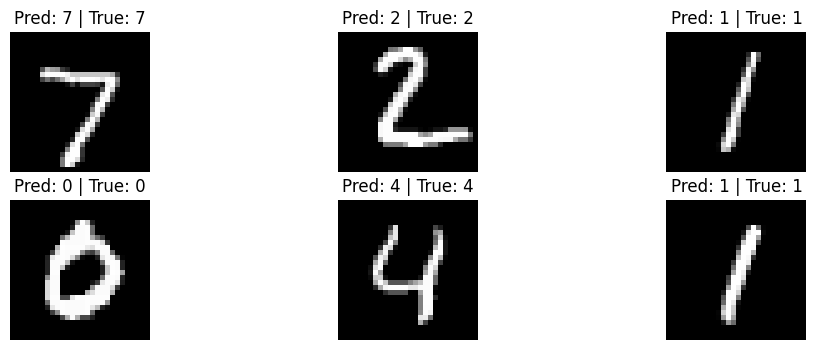

In [15]:
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

with torch.no_grad():
    output = model(example_data.to(device))

plt.figure(figsize=(12, 4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    plt.title(f"Pred: {output.data.max(1)[1][i].item()} | True: {example_targets[i]}")
    plt.axis('off')
plt.show()


Step 8: Plot Training Loss

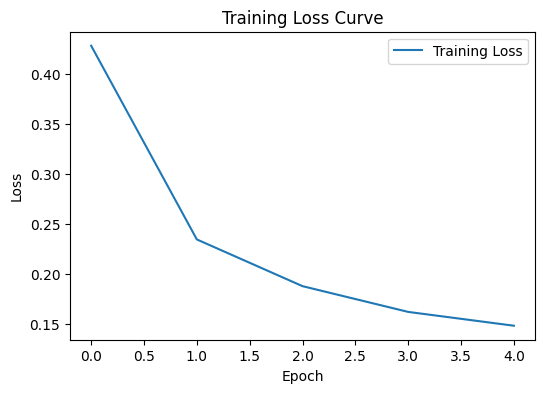

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Training Loss")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [17]:
torch.save(model.state_dict(), "mnist_model.pth")
